# cog20 task-variance clustering under rate + wiring costs

**Question.** Earlier cog20 (20-task) Dale networks did not show Yang-2019-style task-variance clusters, while the
core5 `moo_zoom` networks do under cost constraints (control k≈2.3 vs constrained k≈4-6, silhouette ≈0.32).
Do rate + wiring costs also produce clusters on cog20?

**Setup.** `cmc.lambda_zoom`, `--task-battery all --steps 20000`, 3 seeds at the core5 6x6 grid point closest to
the moo_zoom *middle* budget point (λ_rate=0.267, λ_conn=2.09). Controls: the existing unconstrained `dale_20_*`
checkpoints in `runs/checkpoints/`. Their task variance is recomputed here with `cmc.runner.activity_summary`, using the same eval seeds and batch size.

Caveats: λ was calibrated on core5, so on cog20 it probably constrains less. The control checkpoints are older and may predate the
FIXED_ISSUES changes and the 20000-step setting, so treat them as a qualitative reference only. The exact budget version of this test would be `cmc.moo_zoom --task-battery all`.

In [1]:
import contextlib, io, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from cmc.train_cog import load_checkpoint
from cmc.runner import activity_summary

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ZOOM_DIR = ROOT / "runs/lambda_zoom/dale_cog20_middle_3seed"
CKPT_DIR = ROOT / "runs/checkpoints"
zsum = json.loads((ZOOM_DIR / "summary.json").read_text())
TASKS = zsum["active_tasks"]
EVAL_SEEDS = zsum["eval_seeds"]
EVAL_BS = zsum["args"].get("eval_batch_size", 64)
zoom = pd.read_csv(ZOOM_DIR / "runs.csv")
zoom[["seed", "mean_acc", "min_task_acc", "metabolic_cost", "wiring_cost", "conn_frac", "is_feasible"]]

,seed,mean_acc,min_task_acc,metabolic_cost,wiring_cost,conn_frac,is_feasible
0,0,0.900313,0.496875,0.004444,0.001438,0.030438,False
1,1,0.902656,0.518750,0.005040,0.002088,0.047871,False
2,2,0.890859,0.535937,0.004429,0.001621,0.035677,False


All 3 seeds are **infeasible** (min_task_acc ≈ 0.5). The bottleneck is **dmsnogo** at chance. Most other tasks are near ceiling, and the delay-DM family sits at ~0.75-0.85. So the clustering below describes networks that solve 19/20 tasks, not 20/20.

In [2]:
zoom.filter(like="acc_").T.set_axis([f"seed {s}" for s in zoom.seed], axis=1).round(3)

,seed 0,seed 1,seed 2
acc_fdgo,1.000,1.000,1.000
acc_reactgo,1.000,1.000,1.000
acc_delaygo,1.000,1.000,1.000
acc_fdanti,1.000,1.000,1.000
acc_reactanti,1.000,1.000,1.000
acc_delayanti,1.000,1.000,1.000
acc_dm1,1.000,1.000,1.000
acc_dm2,1.000,0.992,1.000
acc_contextdm1,0.997,0.998,1.000
acc_contextdm2,1.000,0.962,0.998


In [3]:
def load(path):
    with contextlib.redirect_stdout(io.StringIO()):
        return load_checkpoint(path)

nets = {}   # name -> dict(tv, n_e, group)
for p in sorted((ZOOM_DIR / "middle").glob("seed_*.pt")):
    model, cfg, ck = load(p)
    nets[f"middle/{p.stem}"] = dict(tv=np.asarray(ck["task_variance"]), n_e=int(model.n_e), group="middle")

for p in sorted(CKPT_DIR.glob("dale_20_*.pt")):
    model, cfg, ck = load(p)
    if list(ck.get("active_tasks", [])) != TASKS:
        print("skip (task set differs):", p.name); continue
    tv, _ = activity_summary(model, cfg, TASKS, torch.device("cpu"), EVAL_SEEDS, EVAL_BS)
    nets[f"control/{p.stem}"] = dict(tv=tv, n_e=int(model.n_e), group="control")
print(len(nets), "networks:", list(nets))

11 networks: ['middle/seed_00', 'middle/seed_01', 'middle/seed_02', 'control/dale_20_30000_2026_08_30_16_18_58', 'control/dale_20_30000_2026_08_30_19_25_03', 'control/dale_20_30000_2026_08_30_21_13_44', 'control/dale_20_30000_2026_09_04_17_05_15', 'control/dale_20_30000_2026_09_04_23_28_14', 'control/dale_20_50000_2026_09_03_14_06_22', 'control/dale_20_50000_2026_09_05_02_42_22', 'control/dale_20_50000_2026_09_05_02_50_56']


## Clustering (same procedure as moo_zoom_analysis §2.1)

The clustering procedure:

1. Keep the active neurons, i.e. those whose total task variance is above 1% of the maximum.
2. Normalise each neuron's variance vector to its max.
3. Run k-means for k = 2-10 and pick k by silhouette score.

On the 3 middle seeds, a quick pre-check picked k=10 twice and k=2 once, with silhouette ≈0.22-0.24. That suggests the silhouette-vs-k curve is flat, so it is plotted in full rather than reporting only the argmax. The range is extended to 20, because with 20 tasks Yang et al. found ~12-15 clusters.

In [4]:
K_RANGE = range(2, 21)

def tv_clusters(tv, k_range=K_RANGE, seed=0):
    total = tv.sum(axis=0)
    active = total > 1e-2 * total.max()
    norm = tv[:, active] / tv[:, active].max(axis=0, keepdims=True)
    X = norm.T
    scores, labs = {}, {}
    for k in k_range:
        if k >= len(X): break
        lab = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        scores[k], labs[k] = silhouette_score(X, lab), lab
    k = max(scores, key=scores.get)
    lab = labs[k]
    pref = {c: np.argmax(norm[:, lab == c].mean(axis=1)) for c in range(k)}
    order = sorted(range(k), key=lambda c: (pref[c], -norm[pref[c], lab == c].mean()))
    remap = {c: i for i, c in enumerate(order)}
    labels = np.full(tv.shape[1], -1); labels[active] = [remap[c] for c in lab]
    return dict(active=active, norm_full=tv / np.maximum(tv.max(axis=0, keepdims=True), 1e-30),
                labels=labels, k=k, silhouette=scores[k], scores=scores,
                pref_tasks=sorted({TASKS[pref[c]] for c in range(k)}))

for name, n in nets.items():
    n["cl"] = tv_clusters(n["tv"])

stats = pd.DataFrame([dict(net=name, group=n["group"], n_active=int(n["cl"]["active"].sum()),
                           n_active_E=int(n["cl"]["active"][:n["n_e"]].sum()),
                           n_active_I=int(n["cl"]["active"][n["n_e"]:].sum()),
                           k=n["cl"]["k"], silhouette=n["cl"]["silhouette"],
                           n_pref_tasks=len(n["cl"]["pref_tasks"]))
                      for name, n in nets.items()])
display(stats.round(3))
display(stats.groupby("group")[["n_active", "k", "silhouette", "n_pref_tasks"]].agg(["mean", "std"]).round(2))

,net,group,n_active,n_active_E,n_active_I,k,silhouette,n_pref_tasks
0,middle/seed_00,middle,230,180,50,12,0.245,9
1,middle/seed_01,middle,238,186,52,11,0.225,9
2,middle/seed_02,middle,237,186,51,19,0.239,11
3,control/dale_20_30000_2026_08_30_16_18_58,control,255,204,51,2,0.167,2
4,control/dale_20_30000_2026_08_30_19_25_03,control,254,203,51,2,0.199,2
5,control/dale_20_30000_2026_08_30_21_13_44,control,256,204,52,2,0.240,2
6,control/dale_20_30000_2026_09_04_17_05_15,control,256,204,52,7,0.190,5
7,control/dale_20_30000_2026_09_04_23_28_14,control,256,204,52,7,0.163,4
8,control/dale_20_50000_2026_09_03_14_06_22,control,256,204,52,2,0.159,2
9,control/dale_20_50000_2026_09_05_02_42_22,control,256,204,52,2,0.180,2


n_active            k       silhouette       n_pref_tasks      
            mean   std   mean   std       mean   std         mean   std
group                                                                  
control   255.62  0.74   3.38  2.26       0.19  0.03         2.75  1.16
middle    235.00  4.36  14.00  4.36       0.24  0.01         9.67  1.15

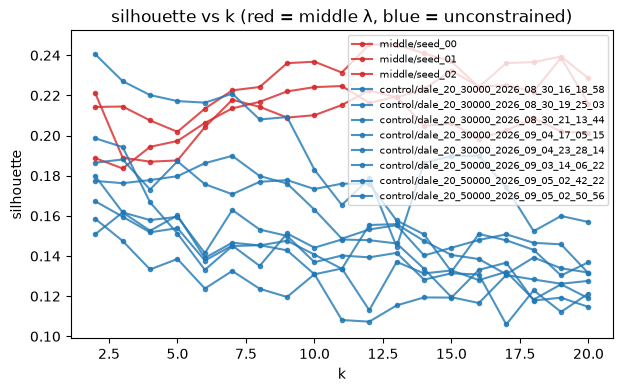

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, n in nets.items():
    s = n["cl"]["scores"]
    ax.plot(list(s), list(s.values()), "-o", ms=3, color="C3" if n["group"] == "middle" else "C0",
            alpha=0.8, label=name)
ax.set_xlabel("k"); ax.set_ylabel("silhouette"); ax.legend(fontsize=7)
ax.set_title("silhouette vs k (red = middle λ, blue = unconstrained)")
plt.show()

## Normalised task-variance heatmaps

Active neurons are sorted by cluster, with E before I inside each cluster. Cyan lines mark cluster boundaries.

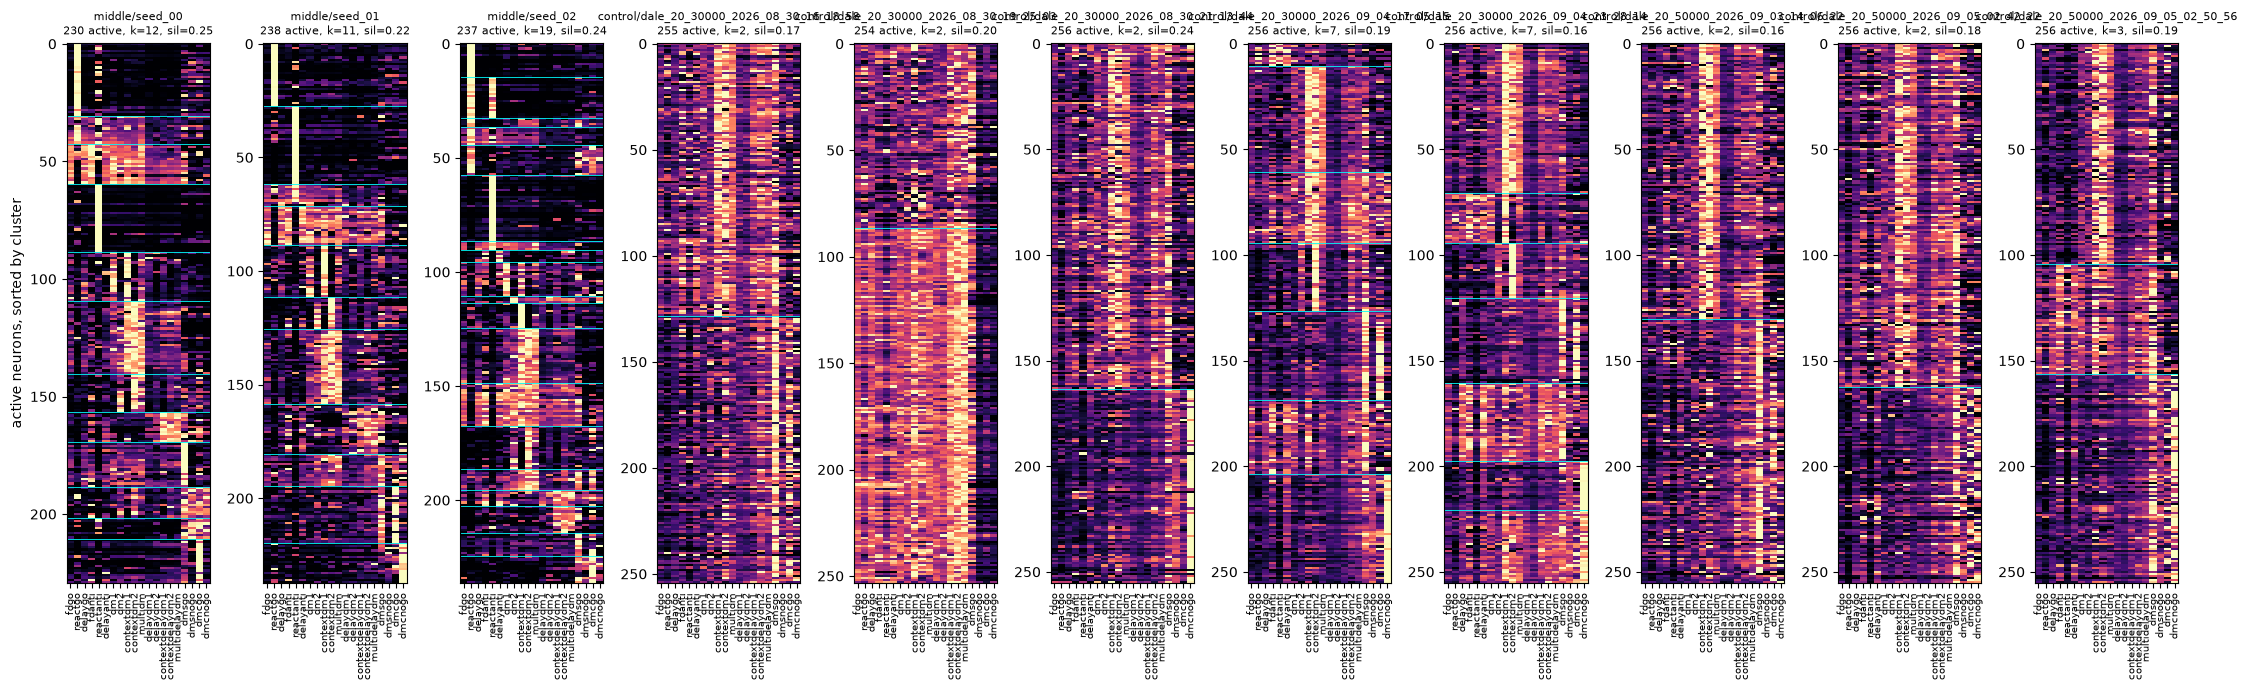

In [8]:
fig, axes = plt.subplots(1, len(nets), figsize=(2 * len(nets), 7))
axes = np.atleast_1d(axes)
for ax, (name, n) in zip(axes, nets.items()):
    cl = n["cl"]
    idx = np.flatnonzero(cl["active"])
    idx = idx[np.lexsort((idx >= n["n_e"], cl["labels"][idx]))]
    ax.imshow(cl["norm_full"][:, idx].T, aspect="auto", cmap="magma", vmin=0, vmax=1, interpolation="nearest")
    for b in np.flatnonzero(np.diff(cl["labels"][idx])) + 0.5:
        ax.axhline(b, color="cyan", lw=0.6)
    ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=90, fontsize=7)
    ax.set_title(f"{name}\n{cl['active'].sum()} active, k={cl['k']}, sil={cl['silhouette']:.2f}", fontsize=8)
axes[0].set_ylabel("active neurons, sorted by cluster")
plt.tight_layout(); plt.show()

## Which tasks get their own cluster?

For each network, this lists the preferred task of each cluster, then the fraction of active neurons whose single most-driving task is each task.

In [7]:
rows = []
for name, n in nets.items():
    norm = n["cl"]["norm_full"][:, n["cl"]["active"]]
    frac = np.bincount(norm.argmax(axis=0), minlength=len(TASKS)) / norm.shape[1]
    rows.append(pd.Series(frac, index=TASKS, name=name))
    print(f"{name:45s} cluster-preferred tasks: {n['cl']['pref_tasks']}")
pd.DataFrame(rows).T.round(2).style.background_gradient(cmap="magma", axis=None)

middle/seed_00                                cluster-preferred tasks: ['contextdelaydm1', 'contextdm1', 'contextdm2', 'dmcgo', 'dmsgo', 'dmsnogo', 'fdanti', 'reactanti', 'reactgo']
middle/seed_01                                cluster-preferred tasks: ['contextdm1', 'contextdm2', 'delayanti', 'dmcgo', 'dmcnogo', 'dmsgo', 'multidelaydm', 'reactanti', 'reactgo']
middle/seed_02                                cluster-preferred tasks: ['contextdelaydm1', 'contextdelaydm2', 'contextdm1', 'contextdm2', 'delayanti', 'dm1', 'dm2', 'dmcgo', 'dmsgo', 'reactanti', 'reactgo']
control/dale_20_30000_2026_08_30_16_18_58     cluster-preferred tasks: ['contextdm1', 'dmsgo']
control/dale_20_30000_2026_08_30_19_25_03     cluster-preferred tasks: ['contextdelaydm2', 'multidelaydm']
control/dale_20_30000_2026_08_30_21_13_44     cluster-preferred tasks: ['contextdm1', 'dmcnogo']
control/dale_20_30000_2026_09_04_17_05_15     cluster-preferred tasks: ['contextdm1', 'contextdm2', 'dmcnogo', 'dmsgo', 'fdanti']


,middle/seed_00,middle/seed_01,middle/seed_02,control/dale_20_30000_2026_08_30_16_18_58,control/dale_20_30000_2026_08_30_19_25_03,control/dale_20_30000_2026_08_30_21_13_44,control/dale_20_30000_2026_09_04_17_05_15,control/dale_20_30000_2026_09_04_23_28_14,control/dale_20_50000_2026_09_03_14_06_22,control/dale_20_50000_2026_09_05_02_42_22,control/dale_20_50000_2026_09_05_02_50_56
fdgo,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000
reactgo,0.140000,0.130000,0.160000,0.010000,0.040000,0.010000,0.010000,0.020000,0.000000,0.000000,0.000000
delaygo,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000
fdanti,0.040000,0.040000,0.030000,0.050000,0.020000,0.020000,0.040000,0.060000,0.040000,0.030000,0.030000
reactanti,0.180000,0.170000,0.190000,0.020000,0.020000,0.020000,0.010000,0.010000,0.020000,0.020000,0.020000
delayanti,0.000000,0.030000,0.020000,0.020000,0.010000,0.000000,0.020000,0.020000,0.000000,0.030000,0.010000
dm1,0.030000,0.030000,0.040000,0.010000,0.000000,0.020000,0.010000,0.010000,0.010000,0.000000,0.000000
dm2,0.030000,0.020000,0.030000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000
contextdm1,0.100000,0.100000,0.130000,0.130000,0.180000,0.140000,0.140000,0.250000,0.180000,0.190000,0.180000
contextdm2,0.110000,0.110000,0.090000,0.170000,0.070000,0.200000,0.200000,0.180000,0.270000,0.150000,0.190000


## Readout

*(Fill in after running.)* What to compare:

- **k and silhouette, middle vs control.** On core5, constraints raised k from ≈2.3 to ≈4-6 at silhouette ≈0.32. A flat silhouette-vs-k curve with values ≈0.2 means the clusters are weak or absent, whatever k the argmax picks.
- **Task-specific clusters.** Do any clusters prefer only one task, like the dmsgo-specific cluster on core5?
- **Interpretation limits.** λ is under-calibrated for cog20, all middle seeds are infeasible on dmsnogo, and the controls come from an older pipeline. A negative result here is weak evidence. The cleaner follow-up is `cmc.moo_zoom --task-battery all`, plus a control trained with the current code (`--points "control=0,0"`, same steps).